#Evaluierung der Metrik-Modelle (MixUp vs. Synthetisch) auf dem Lebenshilfe-Datensatz

Dieses Notebook lädt die beiden trainierten Qualitäts-/Komplexitäts-Metrik-Modelle (**MixUp-Regressor** und **Synthetischer Regressor**) und evaluiert deren Vorhersagen auf dem **Lebenshilfe-Datensatz**:
1. **Setup & Pfade:** Wie in den Übersetzungs-Notebooks (`analyse_dpo_model_mixup.ipynb`).
2. **Modelle & Vokabulare laden:** Dynamische Anpassung an die Modell-Gewichte zur Vermeidung von Size-Mismatch-Fehlern.
3. **Inferenz auf Lebenshilfe-Artikeln & Sätzen:** Berechnung der Komplexitäts-/$\lambda$-Scores für AS und LS.
4. **KDE-Dichteverteilungs-Plots:** Darstellung der Vorhersagen in zwei einzelnen KDE-Plots im Format der Referenzabbildung.

In [1]:
import os
import sys
import json
import glob
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

#Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


##1. KDE-Evaluationsergebnisse laden

In [2]:
CSV_PATH = "results/evaluation/mixup_synthetic_kde_eval.csv"
if not os.path.exists(CSV_PATH):
    CSV_PATH = "../../../results/evaluation/mixup_synthetic_kde_eval.csv"

df_kde = pd.read_csv(CSV_PATH)
print(f"KDE Evaluations-Ergebnisse geladen: {len(df_kde)} Artikel aus {CSV_PATH}")
display(df_kde.head())


##2. Statistische Auswertung

In [6]:
def get_metrics_summary(ls_p, as_p, model_name):
    mean_ls = np.mean(ls_p)
    mean_as = np.mean(as_p)
    std_ls = np.std(ls_p)
    std_as = np.std(as_p)
    
    correct_ls = np.sum(ls_p > 0.5)
    correct_as = np.sum(as_p <= 0.5)
    total = len(ls_p) + len(as_p)
    
    acc = (correct_ls + correct_as) / total
    bacc = ((correct_ls / len(ls_p)) + (correct_as / len(as_p))) / 2.0
    mae = (np.sum(1.0 - ls_p) + np.sum(as_p)) / total
    
    return {
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f} ± {std_ls:.3f}",
        "Ø Lambda (AS)": f"{mean_as:.4f} ± {std_as:.3f}",
        "Separation (LS - AS)": f"{(mean_ls - mean_as):.4f}",
        "Accuracy (Schwelle 0.5)": f"{acc * 100:.2f}%",
        "Balanced Acc": f"{bacc * 100:.2f}%",
        "MAE (Target 1/0)": f"{mae:.4f}"
    }

df_summary = pd.DataFrame([
    get_metrics_summary(ls_preds_mixup, as_preds_mixup, "MixUp-Modell"),
    get_metrics_summary(ls_preds_synth, as_preds_synth, "Synthetisches Metrik-Modell")
])

print("\n=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
display(df_summary)


=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================


,Modell,Ø Lambda (LS),Ø Lambda (AS),Separation (LS - AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,MixUp-Modell,0.7738 ± 0.119,0.1096 ± 0.108,0.6642,96.76%,96.83%,0.1715
1,Synthetisches Metrik-Modell,0.6502 ± 0.322,0.1390 ± 0.113,0.5112,81.42%,82.32%,0.2509


##3. Zwei einzelne KDE-Plots der Dichteverteilung (wie im Beispielbild)

Exakte visuelle Formatierung wie in der Referenzabbildung:
- **Grüne Fläche:** `LS (Einfache Sprache)`
- **Blaue Fläche:** `AS (Alltagssprache)`
- **X-Achse:** `Lambda (Anteil LS)`
- **Y-Achse:** `Dichte`
- **Gitter:** Subtile Hilfslinien (`style="whitegrid"`)

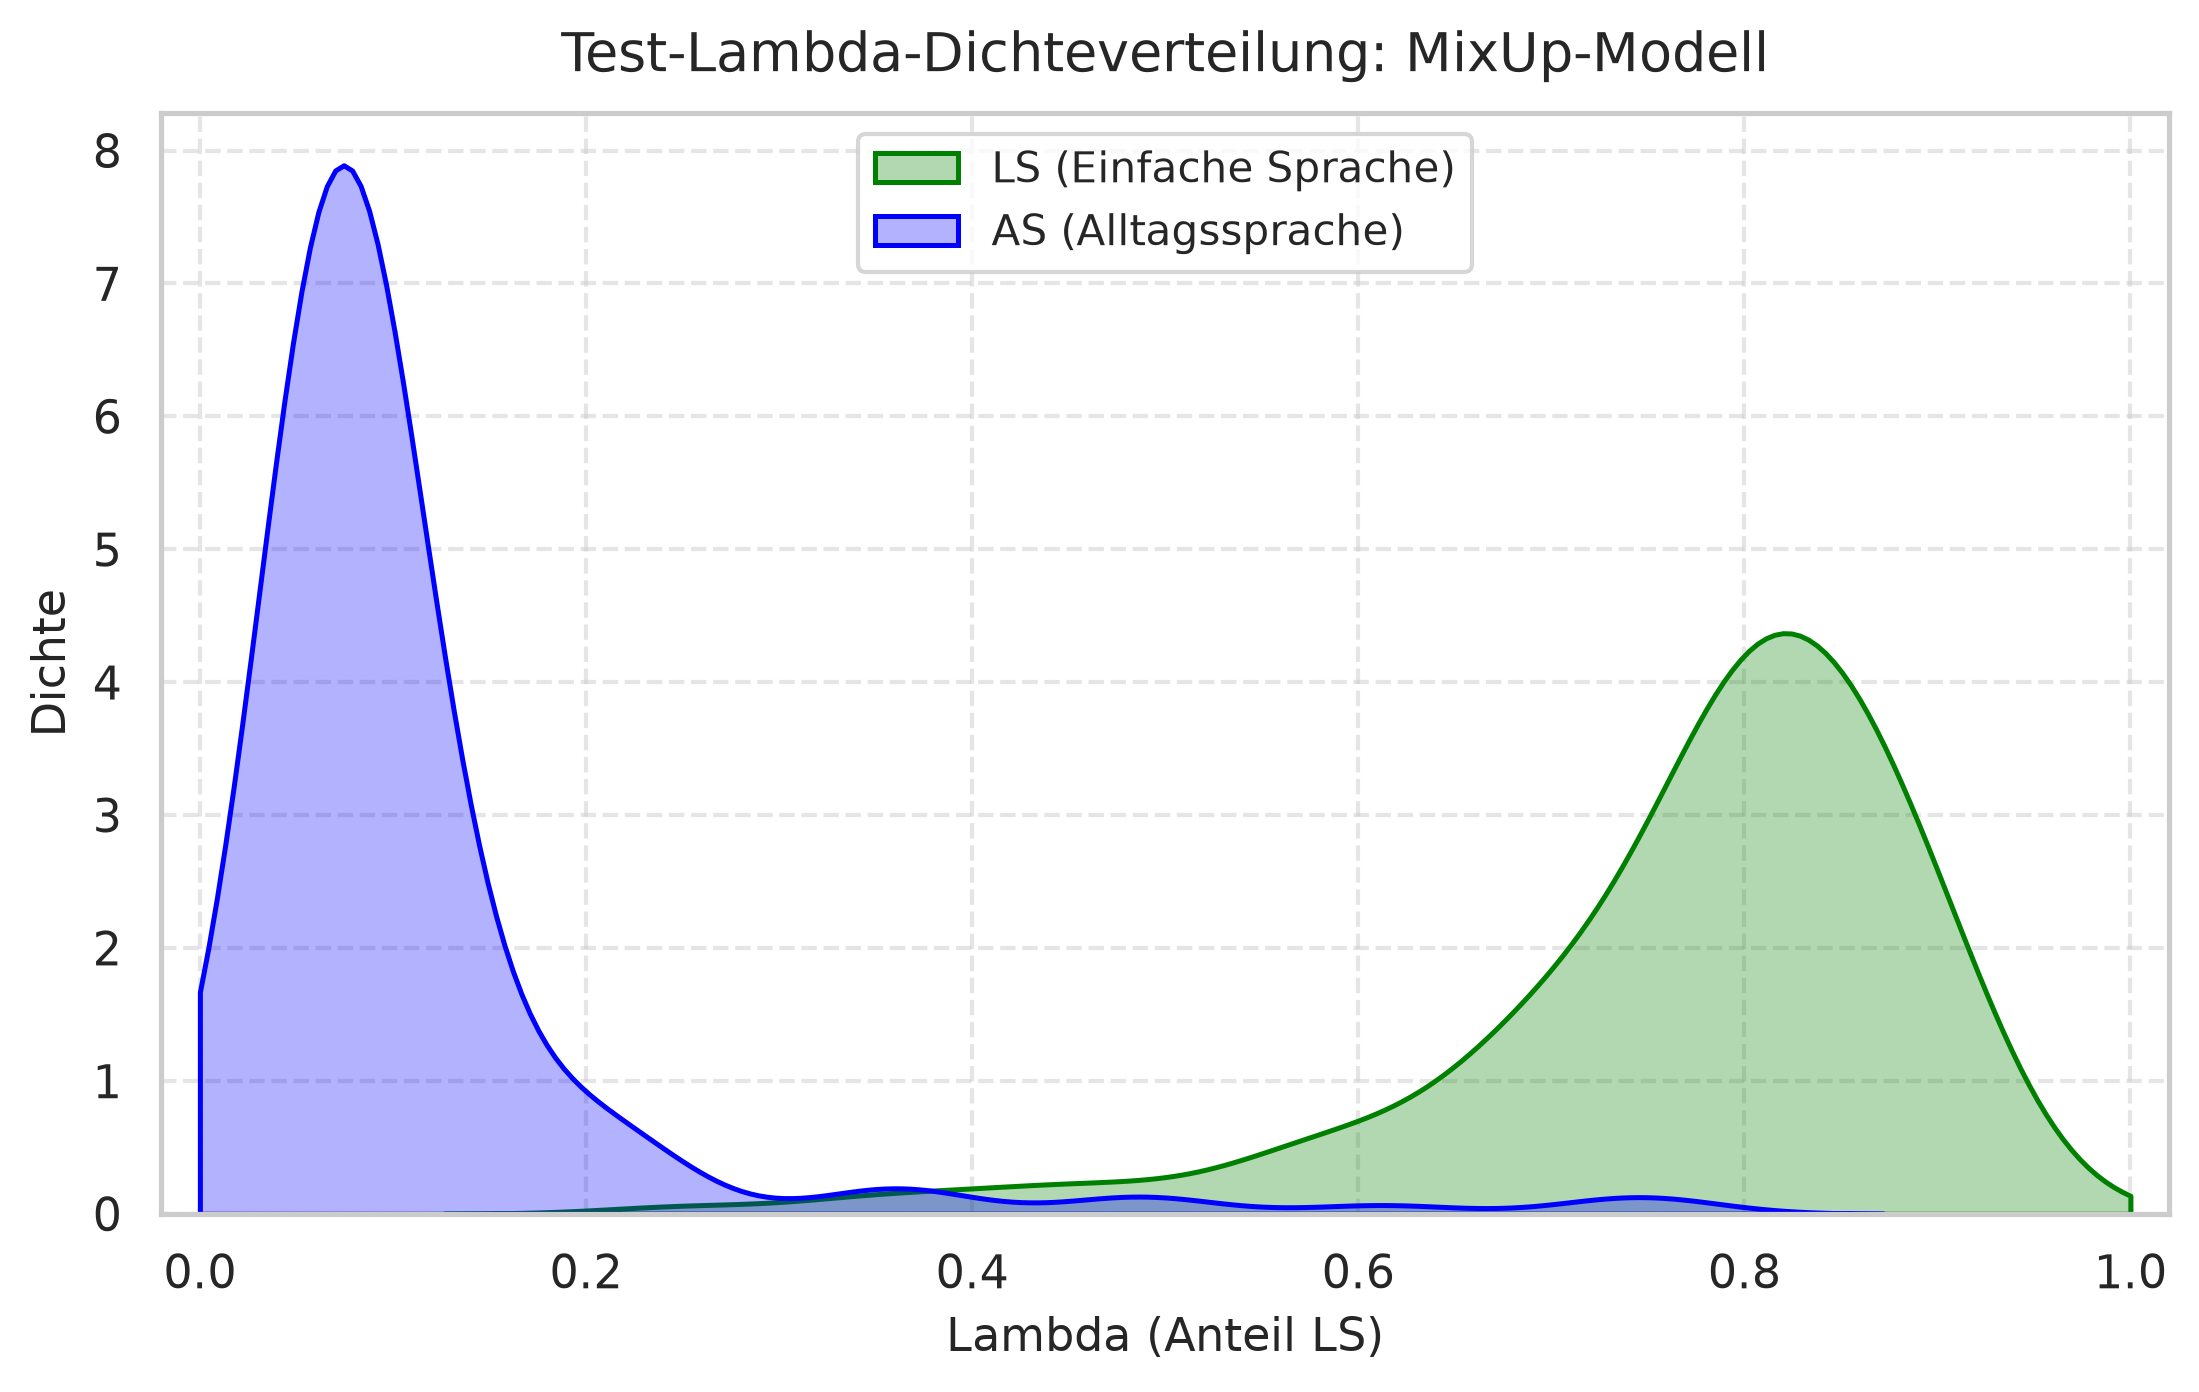

Plot gespeichert: results/plots/kde_mixup_lh_distribution.png


In [7]:
#Set Seaborn Style
sns.set_theme(style="whitegrid")

#Einzelplot: MixUp-Modell
fig1, ax1 = plt.subplots(figsize=(7.5, 4.8), dpi=300)

sns.kdeplot(
    ls_preds_mixup,
    fill=True,
    color="green",
    alpha=0.3,
    edgecolor="green",
    linewidth=1.2,
    label="LS (Einfache Sprache)",
    ax=ax1,
    clip=(0.0, 1.0)
)

sns.kdeplot(
    as_preds_mixup,
    fill=True,
    color="blue",
    alpha=0.3,
    edgecolor="blue",
    linewidth=1.2,
    label="AS (Alltagssprache)",
    ax=ax1,
    clip=(0.0, 1.0)
)

ax1.set_title("Test-Lambda-Dichteverteilung: MixUp-Modell", fontsize=13, pad=10)
ax1.set_xlabel("Lambda (Anteil LS)", fontsize=11)
ax1.set_ylabel("Dichte", fontsize=11)
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(bottom=0)
ax1.legend(loc="upper center", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plot1_path = os.path.join(PLOT_OUTPUT_DIR, "kde_mixup_lh_distribution.png")
fig1.savefig(plot1_path, dpi=300)
plt.show()
print(f"Plot gespeichert: {plot1_path}")

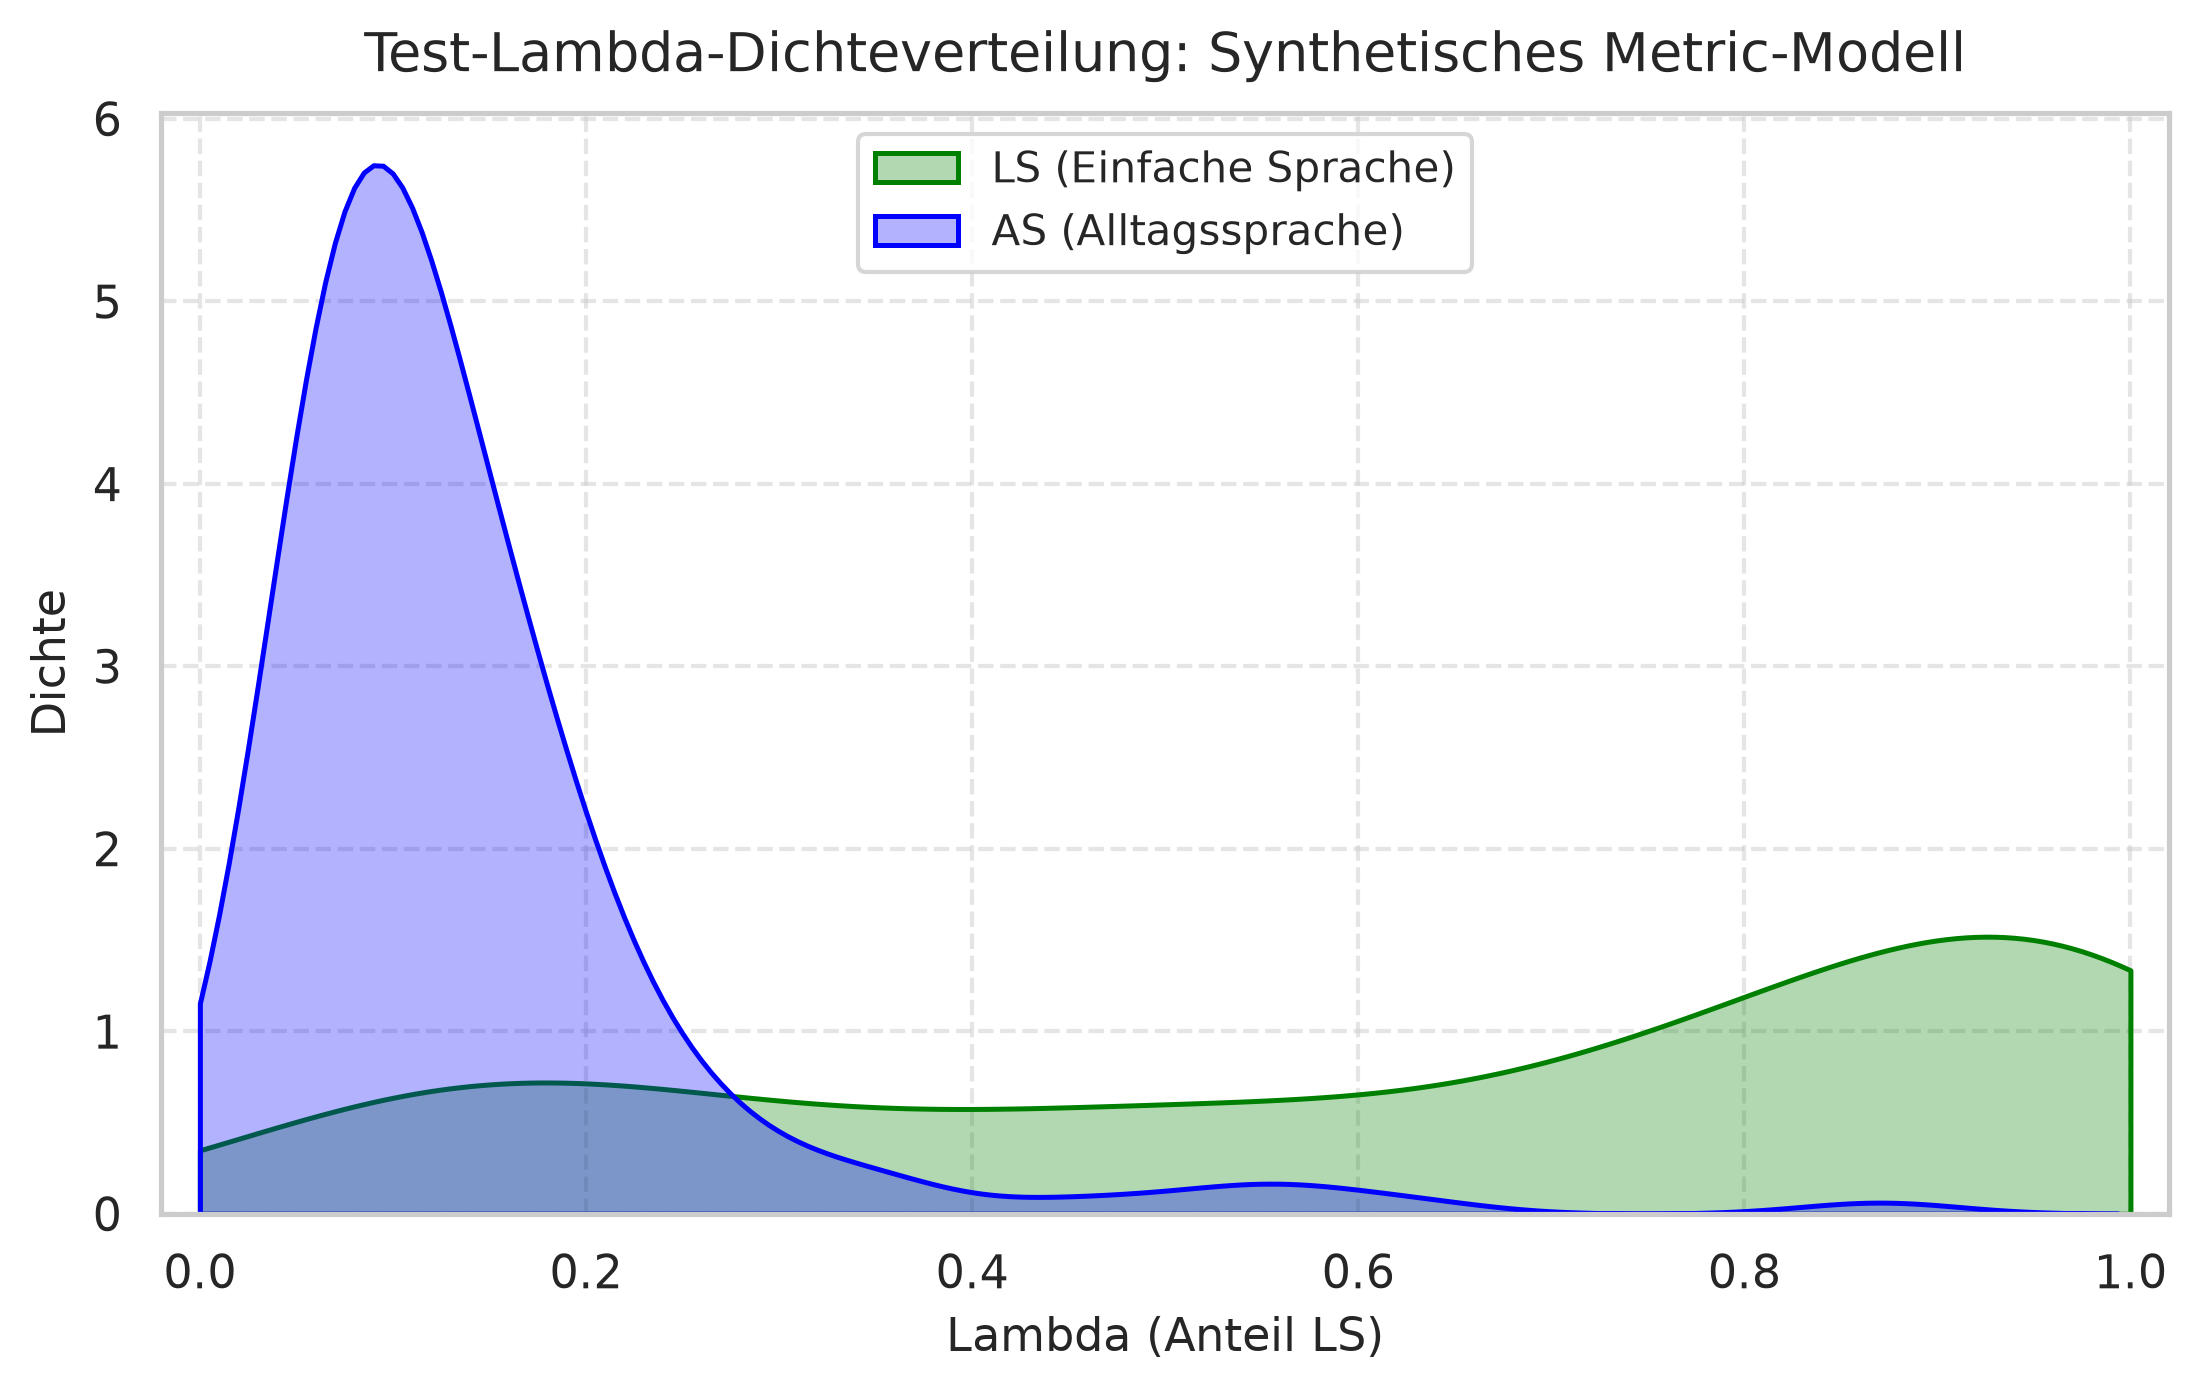

Plot gespeichert: results/plots/kde_synthetic_lh_distribution.png


In [8]:
#Einzelplot: Synthetisches Metrik-Modell
fig2, ax2 = plt.subplots(figsize=(7.5, 4.8), dpi=300)

sns.kdeplot(
    ls_preds_synth,
    fill=True,
    color="green",
    alpha=0.3,
    edgecolor="green",
    linewidth=1.2,
    label="LS (Einfache Sprache)",
    ax=ax2,
    clip=(0.0, 1.0)
)

sns.kdeplot(
    as_preds_synth,
    fill=True,
    color="blue",
    alpha=0.3,
    edgecolor="blue",
    linewidth=1.2,
    label="AS (Alltagssprache)",
    ax=ax2,
    clip=(0.0, 1.0)
)

ax2.set_title("Test-Lambda-Dichteverteilung: Synthetisches Metric-Modell", fontsize=13, pad=10)
ax2.set_xlabel("Lambda (Anteil LS)", fontsize=11)
ax2.set_ylabel("Dichte", fontsize=11)
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(bottom=0)
ax2.legend(loc="upper center", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plot2_path = os.path.join(PLOT_OUTPUT_DIR, "kde_synthetic_lh_distribution.png")
fig2.savefig(plot2_path, dpi=300)
plt.show()
print(f"Plot gespeichert: {plot2_path}")